Arquivo 'nafld1.parquet' baixado com sucesso do bucket 'bronze'.
Arquivo Parquet carregado com sucesso.
Colunas do DataFrame após a leitura:
['age', 'weight', 'height', 'bmi', 'futime', 'male', 'status']

### Quick Data Exploration

Todas as colunas do DataFrame:
['age', 'weight', 'height', 'bmi', 'futime', 'male', 'status']

Colunas do DataFrame antes do df.head():
['age', 'weight', 'height', 'bmi', 'futime', 'male', 'status']


,age,weight,height,bmi,futime,male,status
0,57,60.0,163.0,22.690939,6261,0,0
1,67,70.4,168.0,24.884028,624,0,0
2,53,105.8,186.0,30.453537,1783,1,0
3,56,109.3,170.0,37.830100,3143,1,0
4,68,NaN,NaN,NaN,1836,1,1



Colunas do DataFrame depois do df.head():
['age', 'weight', 'height', 'bmi', 'futime', 'male', 'status']

--- Análises do notebook do Kaggle ---

1. Verificação de valores ausentes:
age          0
weight    4786
height    3168
bmi       4961
futime       0
male         0
status       0
dtype: int64

2. Análise da variável 'age':


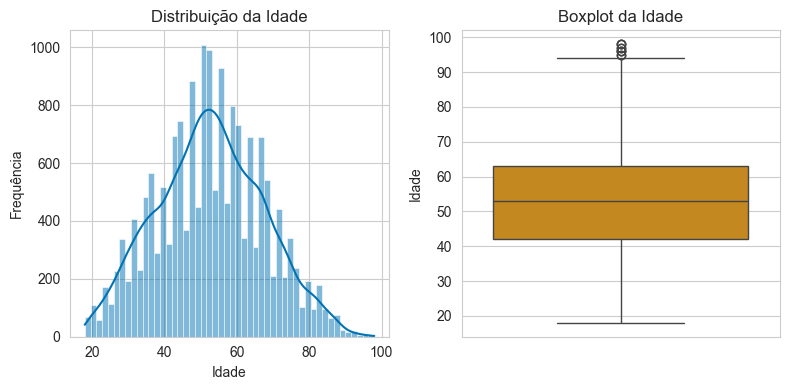


3. Análise da variável 'weight':


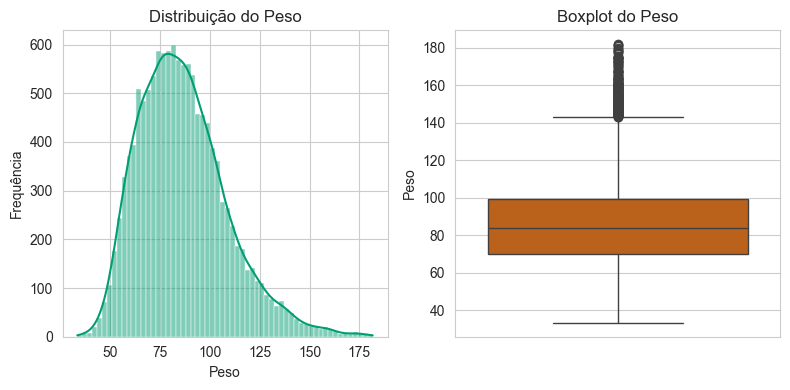


4. Análise da variável 'height':


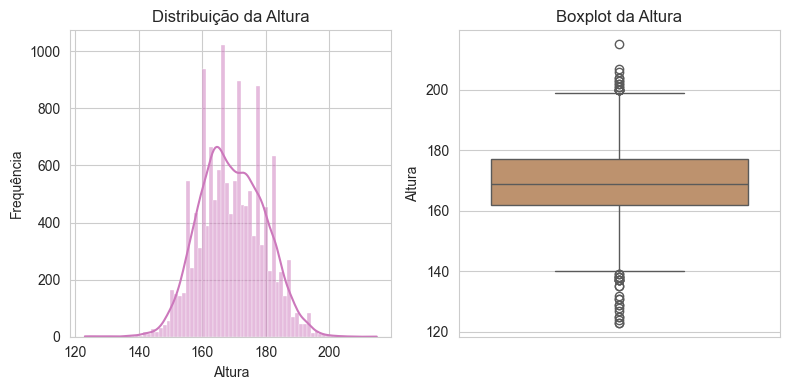


5. Análise da variável 'bmi':


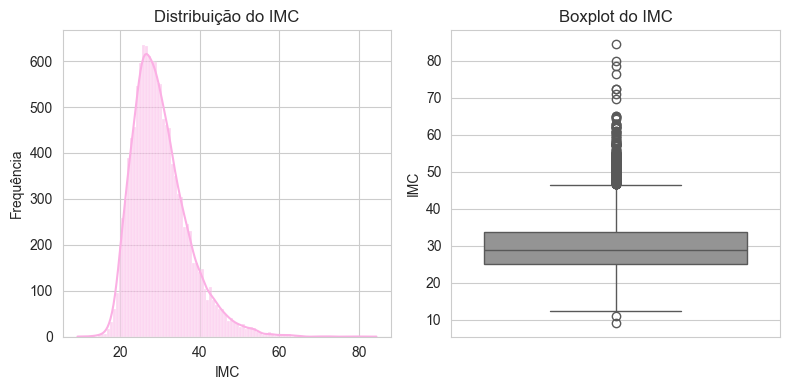


6. Análise da variável 'futime':


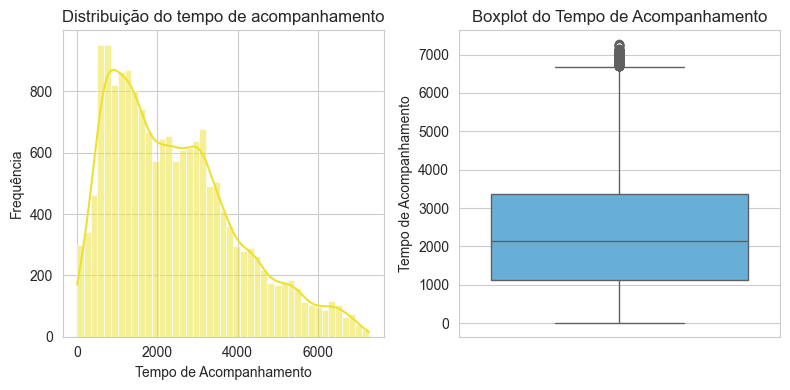


7. Análise da variável 'male':


C:\Users\jesui\AppData\Local\Temp\ipykernel_14280\2690635198.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='male', data=df, palette="colorblind")


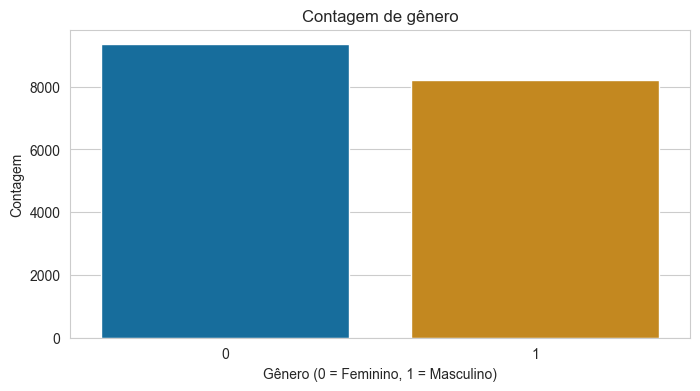


8. Análise da variável 'status':


C:\Users\jesui\AppData\Local\Temp\ipykernel_14280\2690635198.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df, palette="colorblind")


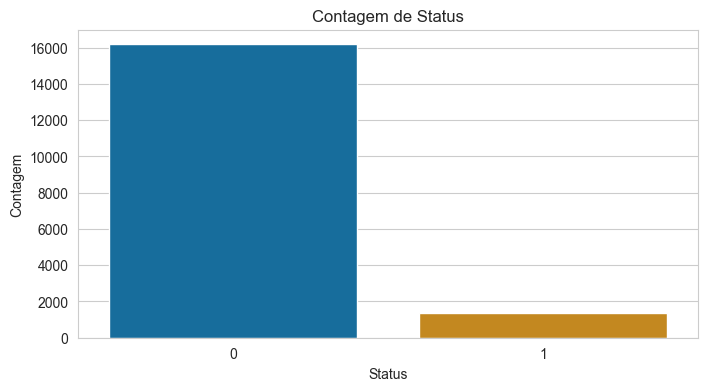


9. Análise da relação entre 'age' e 'bmi':


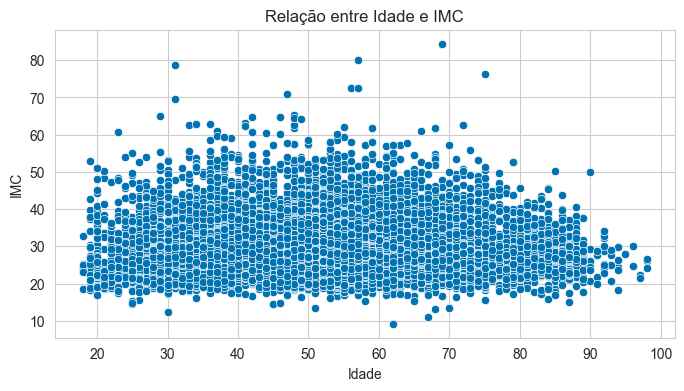


10. Análise da relação entre 'weight' e 'height':


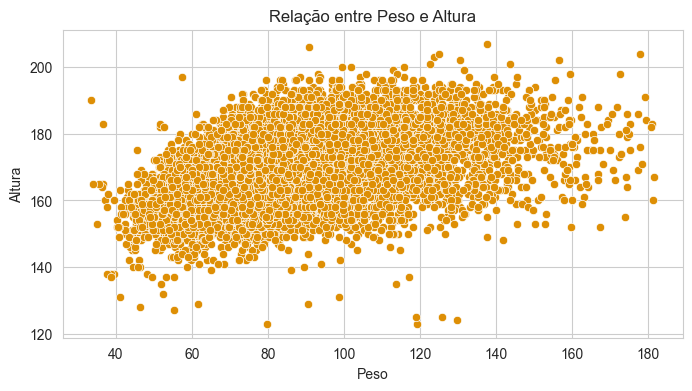


11. Correlação entre as variáveis:


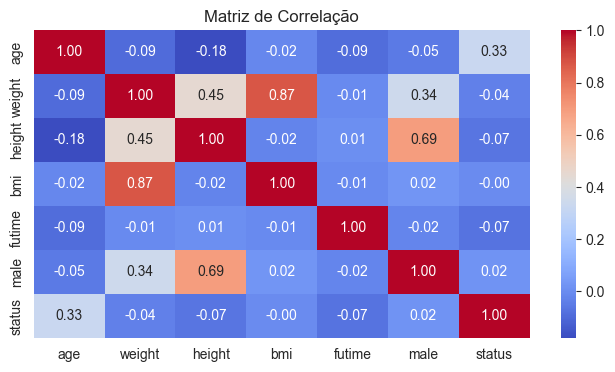


12. Outlier detection:
Outliers encontrados para BMI: []

13. Distribuição de 'futime' por status:


C:\Users\jesui\AppData\Local\Temp\ipykernel_14280\2690635198.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='futime', data=df, palette='colorblind')


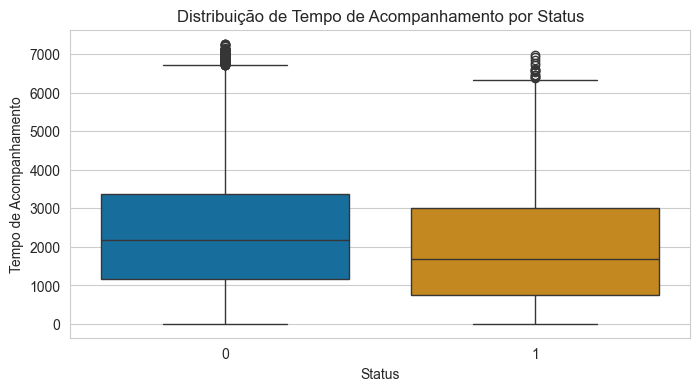


14. Distribuição de 'bmi' por male:


C:\Users\jesui\AppData\Local\Temp\ipykernel_14280\2690635198.py:238: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='male', y='bmi', data=df, palette='colorblind')


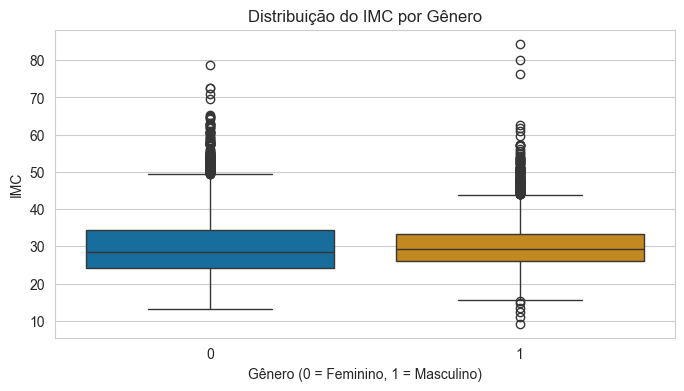

In [19]:
import os
import boto3
import pandas as pd
from dotenv import load_dotenv
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carregando as variáveis de ambiente do arquivo .env
load_dotenv()

# Obtendo as credenciais do MinIO do arquivo .env
minio_url = os.getenv('MINIO_ENDPOINT')
minio_access_key = os.getenv('MINIO_ACCESS_KEY')
minio_secret_key = os.getenv('MINIO_SECRET_KEY')
bucket_name = "bronze"

# Criando o cliente MinIO
s3_client = boto3.client('s3',
                         endpoint_url=f'http://{minio_url}',
                         aws_access_key_id=minio_access_key,
                         aws_secret_access_key=minio_secret_key,
                         config=boto3.session.Config(signature_version='s3v4'))

# Nome do arquivo Parquet no Minio
parquet_file_name = "nafld1.parquet"

# Caminho local para salvar o arquivo baixado do Minio
local_parquet_path = "nafld1_downloaded.parquet"

# Função para baixar o arquivo Parquet do Minio
def download_parquet_from_minio(bucket_name, parquet_file_name, local_parquet_path):
    """Baixa um arquivo Parquet do Minio."""
    try:
        s3_client.download_file(bucket_name, parquet_file_name, local_parquet_path)
        print(f"Arquivo '{parquet_file_name}' baixado com sucesso do bucket '{bucket_name}'.")
    except Exception as e:
        print(f"Erro ao baixar o arquivo Parquet do Minio: {e}")
        return False
    return True

# Baixando o arquivo Parquet do Minio
if download_parquet_from_minio(bucket_name, parquet_file_name, local_parquet_path):
    # Lendo o arquivo Parquet baixado
    try:
        df = pd.read_parquet(local_parquet_path)
        print("Arquivo Parquet carregado com sucesso.")
        # Verificando as colunas logo após a leitura do arquivo
        print("Colunas do DataFrame após a leitura:")
        print(df.columns.tolist())

        # Renomeando a coluna 'case.id.futime' para 'futime'
        if 'case.id.futime' in df.columns:
            df.rename(columns={'case.id.futime': 'futime'}, inplace=True)

    except Exception as e:
        print(f"Erro ao ler o arquivo Parquet: {e}")
        exit()
else:
    print("O download do arquivo Parquet falhou, verifique as credenciais do Minio e o arquivo.")

# --- Quick Data Exploration ---
print("\n### Quick Data Exploration")

# Exibindo TODAS as colunas do DataFrame
print("\nTodas as colunas do DataFrame:")
print(df.columns.tolist())

# Verificando as colunas antes do df.head()
print("\nColunas do DataFrame antes do df.head():")
print(df.columns.tolist())

display(df.head()) # Exibindo df.head como tabela

# Verificando as colunas depois do df.head()
print("\nColunas do DataFrame depois do df.head():")
print(df.columns.tolist())
    
# Função para configurar os gráficos
def configure_plot(figsize=(8, 4)):
    """Configura o estilo e a paleta de cores para visualizações acessíveis."""
    sns.set_style("whitegrid")
    sns.set_palette("colorblind")
    plt.rcParams["figure.figsize"] = figsize

# --- Análises do notebook do Kaggle ---
print("\n--- Análises do notebook do Kaggle ---")
configure_plot()

# 1. Verificação de valores ausentes
print("\n1. Verificação de valores ausentes:")
print(df.isnull().sum())

# 2. Análise da variável 'age'
print("\n2. Análise da variável 'age':")
plt.figure()
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, color=sns.color_palette("colorblind")[0])
plt.title('Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'], color=sns.color_palette("colorblind")[1])
plt.title('Boxplot da Idade')
plt.ylabel('Idade')
plt.tight_layout()
plt.show()

# 3. Análise da variável 'weight'
print("\n3. Análise da variável 'weight':")
plt.figure()
plt.subplot(1, 2, 1)
sns.histplot(df['weight'], kde=True, color=sns.color_palette("colorblind")[2])
plt.title('Distribuição do Peso')
plt.xlabel('Peso')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['weight'], color=sns.color_palette("colorblind")[3])
plt.title('Boxplot do Peso')
plt.ylabel('Peso')
plt.tight_layout()
plt.show()

# 4. Análise da variável 'height'
print("\n4. Análise da variável 'height':")
plt.figure()
plt.subplot(1, 2, 1)
sns.histplot(df['height'], kde=True, color=sns.color_palette("colorblind")[4])
plt.title('Distribuição da Altura')
plt.xlabel('Altura')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'], color=sns.color_palette("colorblind")[5])
plt.title('Boxplot da Altura')
plt.ylabel('Altura')
plt.tight_layout()
plt.show()

# 5. Análise da variável 'bmi'
print("\n5. Análise da variável 'bmi':")
plt.figure()
plt.subplot(1, 2, 1)
sns.histplot(df['bmi'], kde=True, color=sns.color_palette("colorblind")[6])
plt.title('Distribuição do IMC')
plt.xlabel('IMC')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['bmi'], color=sns.color_palette("colorblind")[7])
plt.title('Boxplot do IMC')
plt.ylabel('IMC')
plt.tight_layout()
plt.show()

# 6. Análise da variável 'futime'
print("\n6. Análise da variável 'futime':")
plt.figure()
plt.subplot(1, 2, 1)
sns.histplot(df['futime'], kde=True, color=sns.color_palette("colorblind")[8])
plt.title('Distribuição do tempo de acompanhamento')
plt.xlabel('Tempo de Acompanhamento')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['futime'], color=sns.color_palette("colorblind")[9])
plt.title('Boxplot do Tempo de Acompanhamento')
plt.ylabel('Tempo de Acompanhamento')
plt.tight_layout()
plt.show()

# 7. Análise da variável 'male'
print("\n7. Análise da variável 'male':")
plt.figure()
sns.countplot(x='male', data=df, palette="colorblind")
plt.title('Contagem de gênero')
plt.xlabel('Gênero (0 = Feminino, 1 = Masculino)')
plt.ylabel('Contagem')
plt.show()

# 8. Análise da variável 'status'
print("\n8. Análise da variável 'status':")
plt.figure()
sns.countplot(x='status', data=df, palette="colorblind")
plt.title('Contagem de Status')
plt.xlabel('Status')
plt.ylabel('Contagem')
plt.show()

# 9. Análise da relação entre 'age' e 'bmi'
print("\n9. Análise da relação entre 'age' e 'bmi':")
plt.figure()
sns.scatterplot(x='age', y='bmi', data=df, color=sns.color_palette("colorblind")[0])
plt.title('Relação entre Idade e IMC')
plt.xlabel('Idade')
plt.ylabel('IMC')
plt.show()

# 10. Análise da relação entre 'weight' e 'height'
print("\n10. Análise da relação entre 'weight' e 'height':")
plt.figure()
sns.scatterplot(x='weight', y='height', data=df, color=sns.color_palette("colorblind")[1])
plt.title('Relação entre Peso e Altura')
plt.xlabel('Peso')
plt.ylabel('Altura')
plt.show()

# 11. Correlação entre as variáveis
print("\n11. Correlação entre as variáveis:")
plt.figure()
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

# 12. Outlier detection (exemplo para 'bmi', ajuste conforme necessário)
print("\n12. Outlier detection:")
z_scores = np.abs(stats.zscore(df['bmi']))
outliers = df['bmi'][z_scores > 3]  # Ajuste o threshold (3) conforme necessário
print(f"Outliers encontrados para BMI: {outliers.values}")

# 13. Distribuição de 'futime' por status
print("\n13. Distribuição de 'futime' por status:")
plt.figure()
sns.boxplot(x='status', y='futime', data=df, palette='colorblind')
plt.title('Distribuição de Tempo de Acompanhamento por Status')
plt.xlabel('Status')
plt.ylabel('Tempo de Acompanhamento')
plt.show()

# 14. Distribuição de 'bmi' por male
print("\n14. Distribuição de 'bmi' por male:")
plt.figure()
sns.boxplot(x='male', y='bmi', data=df, palette='colorblind')
plt.title('Distribuição do IMC por Gênero')
plt.xlabel('Gênero (0 = Feminino, 1 = Masculino)')
plt.ylabel('IMC')
plt.show()